# Procesamiento de lenguaje natural (NLP)

---
Curso sabatino

Por: Cesar Macias

Duración: 5 horas

---

Contenido:

1. El lenguaje natural
2. Conocimiento del lenguaje
3. Vectorización
4. Extracción de entidades (NER)
5. Análisis de sentimientos
6. API de Open AI

---

<font size="5">😖 Para tí, ¿Qué es el procesamiento de lenguaje natural? 😱</font>

---

## 1. El lenguaje natural

El lenguaje natural es la lengua o idioma que usamos los humanos para comunicarnos, ya sea de forma verbal o escrita. Para lograr esta comunicación, los seres humanos hemos desarrollado componentes cada vez de mayor complejidad como lo son:
- **Palabras:** la unidad básica del lenguaje, tienen su propio significado (representan mediante símbolos nuestras conceptualizaciónes mentales. P. ej. Gato, conejo, perro, vehículo, computadora)
- **Frases:** mediante la combinación de las palabras, de forma coherente, se conforman las unidades semánticas o frases (p. ej. "la computadora sirve para programar")
- **Oraciones:** es una colección de frases que expresa una idea completa y concreta (p. ej. "Las computadoras sirven para trabajar, uno de los posibles trabajos que se pueden realizar con las computadoras es la programación. Pero también pueden usarse para jugar y chatear.")
- **Documento:** Es un texto (puede ser una frase, una oración o un conjunto de oraciones) relacionado con algún tema en específico
- **Corpus** Es un conjunto de docuentos referentes a una tarea en específico cuyo propósito obedece al objetivo de la tarea (clasificación, generación automática, regresión)
- **Corpora:** Una colección de corpus

---

<font size="5">Procesamiento del lenguaje natural</font>

<font size="3">"Es una rama de la inteligencia artificial, que se enfoca en la interacción entre las computadoras y el lenguaje humano"</font>

---

### Del lenguaje natural al lenguaje máquina

Comencemos recordando cómo es que las computadoras interpretan la información.

Lenguaje de programación 🖥 --> Intérprete 🤖 --> Binario --> CPU

Entonces, ¿Cómo le enseñamos lenguaje natural a una computadora?

In [1]:
!git clone https://github.com/CCogS-Mx/text-preprocessing.git
import sys
sys.path.append('./text-preprocessing/scripts/Eliza/')

Cloning into 'text-preprocessing'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 147 (delta 59), reused 120 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (147/147), 75.12 KiB | 2.35 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [3]:
# Aquí ejecutamos el chat bot basado en eliza
!python3 ./text-preprocessing/scripts/Eliza/asistente_v3.py

Introduce tu nombre / Type your name:
>salva
lenguage / language [0: Español, 1: English, 2: Transalte]:
>0
Asistente

**************************** Instrucciones  ****************************
Puedes hablar conmigo utilizando lenguaje español común, con letras
mayúsculas y minúsculas, y su puntuación.
Escribe "ayuda" para conocer qué puedo hacer
Escribe "salir" para terminar.

Buenas noches Salva ¿Cómo puedo ayudarte?
Salva > ayuda
Asistente > Puedes pedirme cosas cómo:
- "Dame la hora"
- "¿Qué día es hoy?"
- "Cuentame un chiste"
- "Dame la fecha"
- "¿Cómo te llamas?"
- "Necesito ..."
- etc.

 y recuerda, no te preocupes por la puntuación y la acentuación
Salva > dame la hora
Asistente > Son las: 20:32:14
Salva > dame la fecha
Asistente > Hoy es: 26 / 07 / 2025
Salva > nesecito agua 
Asistente > ...
Salva > q
Asistente > Si pudiera ser otra cosa, definitivamente no sería un asistente ja ja ja
Salva > q paso
Asistente > Cuentame más.
Salva > 1
Asistente > Interesante
Salva > 2
Asistente 


Como pudimos apreciar, podemos "enseñar" lenguaje a la computadora limitando el lenguaje y el entorno en el que queremos que se desempeñe. Pero esto no es sufuciente, ya que realmente la computadora sigue ejecutando instrucciones que le hemos dado para realizar esas conversiones, con respuestas predefinidas. Por el momento esto nos vale, pero vayamos más a profundidad.

Entonces ¿cómo hago que la ocmputadora entienda lo que le escribo? 🙀 y no solo sean respuestas predefinidas o respuestas sin coherencia.

- Alice: "Hola Bob, ¿Cómo estás?"
- Bob2000: "Estás gato sombrero azul como bien"

Para lograr que la máquina nos comprenda, primero debemos familiarizarnos con cierto **conocimiento del lenguaje** que debemos enseñarle para que mejore su comprensión. Esto lo veremos en la siguiente sección.

---

## 2. Conocimiento del lenguaje

Recursos para esta sección

- [Spacy](https://spacy.io/)
- [NLTK](https://www.nltk.org/)
- [Graphviz](https://graphviz.org/)

Para nosotros, los seres humanos, la comunicación entre los unos y los otros es muy sencilla. Pero qué de todo sucede para realizar esta comunicación ¿Cómo hacemos del lenguaje algo que se pueda estudiar? Para esto, la Lingüística estableció las bases fundamentales para el estudio del lenguaje que podemos englobar en el denominado conocimiento del lenguaje y es:

- **Fonética y fonología$^*$:** Estudian los sonidos lingüísticos y sus significados
- **Morfología:** El estudio de las relaciones de los componentes importantes de las palabras
- **Sintáxis:** El estudio de las relaciones estructurales entre palabras
- **Semántica:** estudio del significado de las palabras
- **Pragmática$^*$:** Estudio de cómo usamos el lenguaje para alcanzar objetivos
- **Discurso$^*$:** El estudio de las unidades lingüísticas más grandes que una simple aparición

<font size="5">¿Qué es? y ¿Cómo implementamos el conocimiento del lenguaje?</font>



---

### 2.1. Morfología
El estudio de la forma en la que están construidas las palabras a partir de unidades básicas de significado llamadas morfemas.

#### Morfemas
Para clasificar a los morfemas, se usa una de las convencioes que es:
- Morfemas léxico o lexemas (stem)
- Morfemas gramaticales
  - Prefijos: se anteponen al lexema y modifican su significado
  - Sufijos: se posponen al lexema
  - Interfijos: unen al lexema y al sufijo para evitar fonética problemática
- Lemas: Son la forma básica de las palabras
Analicemos el lexema "gat"

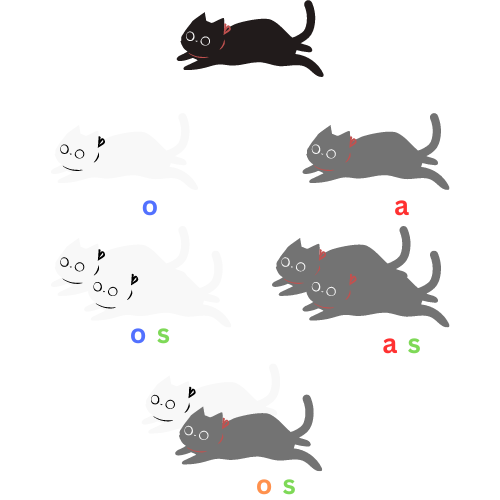

#### La morfología en el PLN

En el procesamiento de lenguaje natural, la morfología nos sirve para:
- **Segmentación y lematización:** divide las palabras en morfemas o lemas para facilitar el análisis
- **Análisis morfológico:** se determina la categoría gramatical de cafa palabra en una oración

##### Segmentación

In [4]:
# Importamos NLTK
import nltk

# De NLTK importamos el stemmer multilingüe
from nltk.stem import SnowballStemmer

In [5]:
# Inicializamos el stemmer multilingüe en idioma Español
stemmer = SnowballStemmer(language='spanish')

# Ahora hagamos una lista de palabras para analizar lo que hace un stemmer
palabras = ['trabajador', 'trabajar', 'trabajadora', 'trabajó']

# Imprimimos los encabezados de las columnas
print("{0:15}{1:15}".format("--Palabra--","--Morfema--"))

# Para cada palabra en la lista de palabras, imprimimos su stem (raiz) o morfema
for palabra in palabras:
   print ("{0:15}{1:15}".format(palabra, stemmer.stem(palabra)))

--Palabra--    --Morfema--    
trabajador     trabaj         
trabajar       trabaj         
trabajadora    trabaj         
trabajó        trabaj         


##### Lematización

In [6]:
# Importamos SpaCy
import spacy

# Y descargamos el modelo preentrenado en un corpus de noticias en Español
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 81.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [7]:
# Inicializamos el lematizador con el modelo preentrenado antes descargado
lematizador = spacy.load("es_core_news_sm")

# Creamos un texto al unir las palabras y lo pasamos al lematizador
print(f"palabras unidas: {' '.join(palabras)}\n")
doc = lematizador(' '.join(palabras))

# Imprimimos la palabra y su lema
print("{0:15}{1:15}".format("--Palabra--","--Lema--"))
for i, palabra in enumerate(palabras):
   print ("{0:15}{1:15}".format(palabra, doc[i].lemma_))

palabras unidas: trabajador trabajar trabajadora trabajó

--Palabra--    --Lema--       
trabajador     trabajador     
trabajar       trabajar       
trabajadora    trabajador     
trabajó        trabajar       


##### Análisis morfológico



In [8]:
# Inicializamos el lematizador
lematizador = spacy.load("es_core_news_sm")

# Pasamos las palabras unidas en un texto único
doc = lematizador(' '.join(palabras))


# Para cada palabra obtenemos el morfema, el lema y su categoría gramatical
print("{0:15}{1:15}{2:15}{3:50}".format("--Palabra--","--Morfema--", "--Lema--", "--Categoría--"))
for i, palabra in enumerate(palabras):
   print ("{0:15}{1:15}{2:15}{3:50}".format(palabra, stemmer.stem(palabra), doc[i].lemma_, str(doc[i].morph)))

--Palabra--    --Morfema--    --Lema--       --Categoría--                                     
trabajador     trabaj         trabajador     Gender=Masc|Number=Sing                           
trabajar       trabaj         trabajar       VerbForm=Inf                                      
trabajadora    trabaj         trabajador     Gender=Fem|Number=Sing                            
trabajó        trabaj         trabajar       Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbForm=Fin


Ahora, analicemos la siguiente frase:

"El puerquito tiene sombrero de copa blanco, un monóculo, y un elegante smoking"

In [ ]:
frase = 'El puerquito tiene sombrero de copa blanco, un monóculo, y un elegante smoking'

# Quitamos las comas de la frase para que el stemmer lo pueda procesar
frase_plana = ''.join(frase.split(','))

# Inicializamos el lematizador
lematizador = spacy.load("es_core_news_sm")

# Pasamos la frase sin modificar al lematizador
doc = lematizador(frase)

# Agregamos caracteres al final de la la frase sin comas para que sea del mismo tamaño
fr = frase_plana.split(' ') + ['_', '_']

# Para cada palabra de la frase obtenemos el morfema, el lema y su categoría gramatical
print("{0:15}{1:15}{2:15}{3:50}".format("--Palabra--","--Morfema--", "--Lema--", "--Categoría--"))
for i, palabra in enumerate(fr):
   print ("{0:15}{1:15}{2:15}{3:50}".format(palabra, stemmer.stem(palabra), doc[i].lemma_, str(doc[i].morph)))

--Palabra--    --Morfema--    --Lema--       --Categoría--                                     
El             el             el             Definite=Def|Gender=Masc|Number=Sing|PronType=Art 
puerquito      puerquit       puerquito      Gender=Masc|Number=Sing                           
tiene          tien           tener          Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin
sombrero       sombrer        sombrero       Gender=Masc|Number=Sing                           
de             de             de                                                               
copa           cop            copa                                                             
blanco         blanc          blanco         Gender=Masc|Number=Sing                           
un             un             ,              PunctType=Comm                                    
monóculo       monocul        uno            Definite=Ind|Gender=Masc|Number=Sing|PronType=Art 
y              y              monócul

---

### 2.2 Sintáxis

Es el estudio formal de las relaciones entre las palabras

#### Etiquetado gramatical

El etiquetado gramatical o _Part-of-Speech_ es de gran utilidad ya que nos proporciona una cantidad significativa de información sobre las palabras en una frase. Mediante el POS podemos darle herramientas a la computadora para distinguir entre verbos, pronombres, adjetivos, etc.

In [9]:
# Sigamos analizando la misma frase
frase = 'El puerquito tiene sombrero de copa blanco, un monóculo, y un elegante smoking'

# Removemos las comas para el stemmer
frase_plana = ''.join(frase.split(','))

# Pasamos la frase sin modificar al lematizador
lematizador = spacy.load("es_core_news_sm")

# Pasamos la frase sin modificar al lematizador
doc = lematizador(frase)

# Agregamos caracteres al final de la la frase sin comas para que sea del mismo tamaño
fr = frase_plana.split(' ') + ['_', '_']

# Para cada palabra de la frase obtenemos el morfema, el lema y su categoría gramatical y su POS
print("{0:15}{1:15}{2:15}{3:15}".format("--Palabra--","--Morfema--", "--Lema--", "--POS--"))
for i, palabra in enumerate(fr):
   print ("{0:15}{1:15}{2:15}{3:15}".format(palabra, stemmer.stem(palabra), doc[i].lemma_, doc[i].pos_))

--Palabra--    --Morfema--    --Lema--       --POS--        
El             el             el             DET            
puerquito      puerquit       puerquito      NOUN           
tiene          tien           tener          VERB           
sombrero       sombrer        sombrero       NOUN           
de             de             de             ADP            
copa           cop            copa           PROPN          
blanco         blanc          blanco         ADJ            
un             un             ,              PUNCT          
monóculo       monocul        uno            DET            
y              y              monóculo       NOUN           
un             un             ,              PUNCT          
elegante       eleg           y              CCONJ          
smoking        smoking        uno            DET            
_              _              elegante       ADJ            
_              _              smoking        NOUN           


#### El lexicón

Son colecciones de palabras o frases que tienen asociadas etiquetas o meta-informacion de algún tipo (definicionaes, POS tags, significados gramaticales, etc ...)

In [10]:
lex_cocina = {
    'abrillantar' : 'dar brillo a un preparado con jalea o grasa',
    'acanalar' : 'hacer canales o estrías en el exterior de un producto crudo',
    'bañar' : 'cubrir completamente un alimento con líquido espeso para que permanezca sobre el',
    'ligar' : 'añadir a una elaboración, un elemento de ligazón para espesar. Mezclar diversos ingredientes de forma homogénea'
}

#### Árboles sintácticos

Es la representación mediante una estructura de tipo árbol jerárquico de los diferentes elementos de una frase u oración.


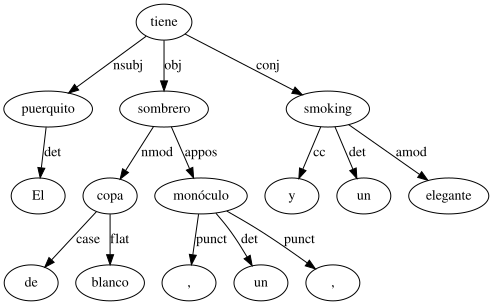

In [11]:
# Importamos graphviz
import graphviz

# Sigamos analizando la misma frase
sentence = 'El puerquito tiene sombrero de copa blanco, un monóculo, y un elegante smoking'

# Pasamos la frase sin modificar al lematizador
lematizador = spacy.load("es_core_news_sm")

# Pasamos la frase sin modificar al lematizador
doc = lematizador(frase)

# Inicializamos el dibujador del árbol sintáctico
dot = graphviz.Digraph(comment='Árbol sintáctico')

# Creamos los nodos y aristas del árbol con la palabra (nodo) y su dependencia gramatical (aristas)
for token in doc:
    dot.node(str(token.i), token.text)
    if token.head != token:
        dot.edge(str(token.head.i), str(token.i), label=token.dep_)

# Save the graph as a PNG file
dot.render('syntactic_tree', format='png', cleanup=True)

dot

### 2.3 Semántica

Es el estudio del significado de las expresiones lingüísticas. ¿Cómo el significado de una expresión se relaciona con los significados de las frases, palabras y morfemas que la componen?

In [12]:
nltk.download('omw') # Descargar la versión de WordNet en español
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet as wn

[nltk_data] Downloading package omw to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


#### Homonimia
Es la relación que existe entre palabras que tienen la misma forma, pero significados diferentes, también se les conoce como homónimos, pueden ser textuales o fonéticos.
- Homófonos: palabras que suenan idénticas pero se escriben diferente (p. ej. "Hola" y "ola")
- Homógrafos: palabras ortográficamente iguales pero con significados diferentes que normalmente depenen del contexto (p. ej. "haya", "ve", "cerca")

#### Polisemia
Este caso se da cuando tenemos una palabra con varios significados relacionados.

**"Algunos bancos son más estrictos con los donantes, meintras que algunos otros son más laxos"**

#### Sinonimia

Palabras ortográficamente diferentes pero que tienen el mismo significado.

- **"El uso de sinónimos no altera el significado de las frases, pero si su contenido"**
- **"El uso de sinónimos no modifica el significado de las frases, pero si su contenido"**

Ahora vemos los conjuntos de sinónimos o synsets, estos contienen las palabras que se han identificado como sinónimos de una palabra, por ejemplo la palabra carro.

In [ ]:
# synset (conjunto de sinónimos)
ss = wn.synsets('carro', lang='spa')
ss

[Synset('car.n.01'),
 Synset('carriage.n.04'),
 Synset('carrier.n.02'),
 Synset('cart.n.01'),
 Synset('chariot.n.02'),
 Synset('cartload.n.01')]

In [ ]:
# Explorando los synsets
for syn in ss:
  print(syn.name(), ': ', syn.definition())
  for name in syn.lemma_names():
    print(' * ', name)
  print('')

car.n.01 :  a motor vehicle with four wheels; usually propelled by an internal combustion engine
 *  car
 *  auto
 *  automobile
 *  machine
 *  motorcar

carriage.n.04 :  a machine part that carries something else
 *  carriage

carrier.n.02 :  a self-propelled wheeled vehicle designed specifically to carry something
 *  carrier

cart.n.01 :  a heavy open wagon usually having two wheels and drawn by an animal
 *  cart

chariot.n.02 :  a two-wheeled horse-drawn battle vehicle; used in war and races in ancient Egypt and Greece and Rome
 *  chariot

cartload.n.01 :  the quantity that a cart holds
 *  cartload



In [ ]:
# Este bloque de código solo contiene las funciones para visualizar los hipónimos
# e hiperónimos

# * http://www.randomhacks.net/2009/12/29/visualizing-wordnet-relationships-as-graphs/
# * http://dlacombejr.github.io/programming/2015/09/28/visualizing-cifar-10-categories-with-wordnet-and-networkx.html

import networkx as nx # Librería para construir grafos
import matplotlib.pyplot as plt

# Construir el grafo a partir de las relaciones del sinset que me interesa
def closure_graph(synset, fn):
    seen = set()
    graph = nx.DiGraph()
    labels = {}

    def recurse(s):
        if not s in seen:
            seen.add(s)
            labels[s.name] = s.name().split('.')[0]
            graph.add_node(s.name)
            for s1 in fn(s):
                graph.add_node(s1.name)
                graph.add_edge(s.name, s1.name)
                recurse(s1)

    recurse(synset)
    return graph, labels

# Dibujar el grafo
def draw_text_graph(G, labels):
    plt.figure(figsize=(18,12))
    pos = nx.planar_layout(G, scale=18)
    nx.draw_networkx_nodes(G, pos, node_color="red", linewidths=0, node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=20, labels=labels)
    nx.draw_networkx_edges(G, pos)
    plt.xticks([])
    plt.yticks([])

#### Hipónimos

Pares de palabras cuyo lexema denota una subclase de otro.

- Vehículo --> Carro --> Taxi

car.n.01


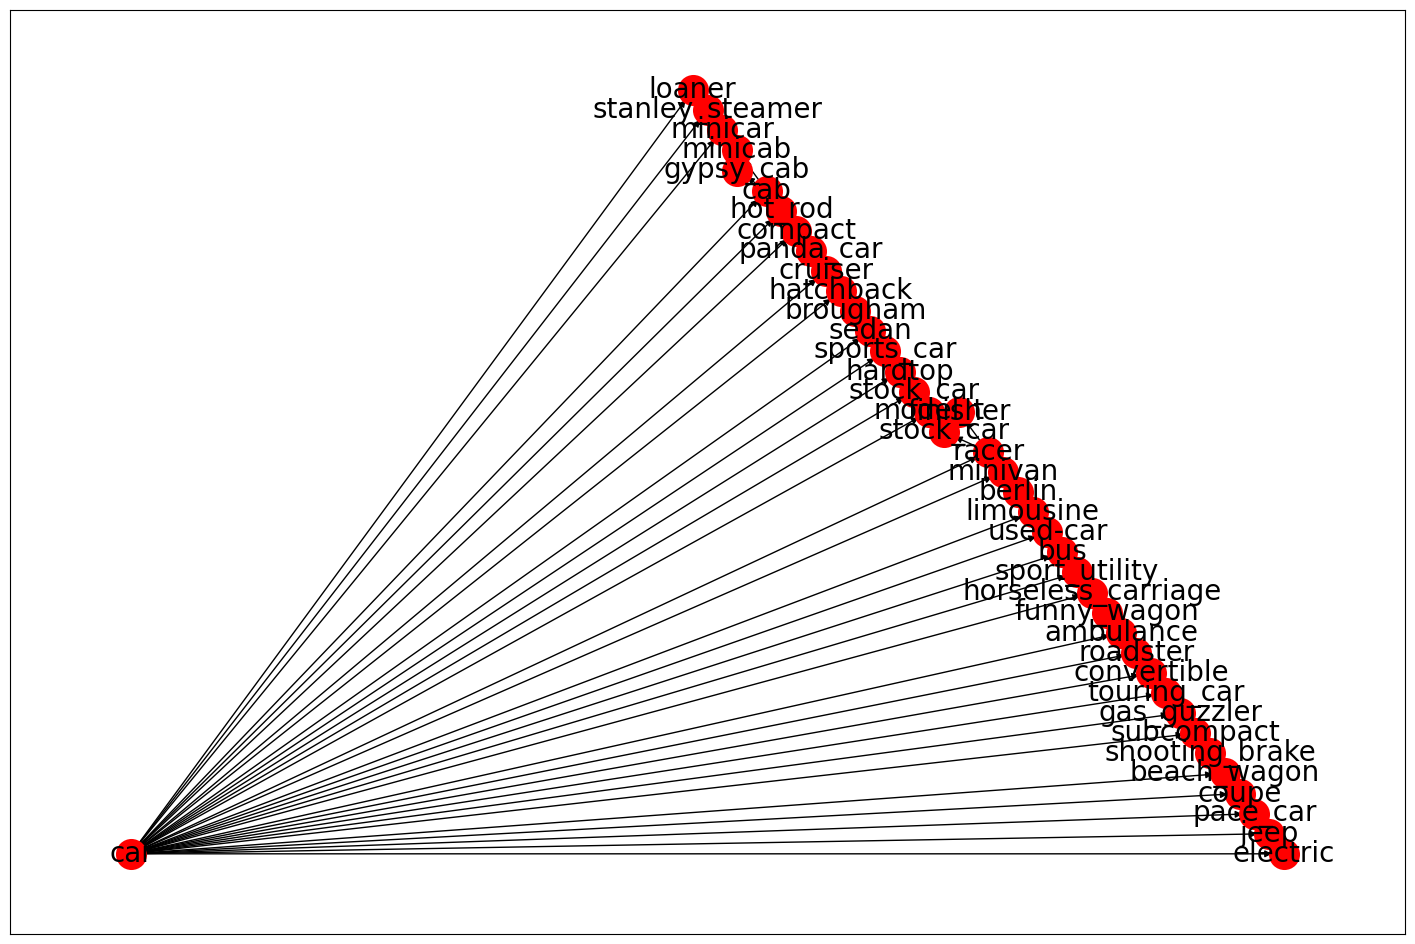

In [ ]:
print(ss[0].name())
G, labels = closure_graph(ss[0], fn = lambda s: s.hyponyms())
draw_text_graph(G, labels)

#### Hiperónimos

Al contrario de los hipónimos, los hiperónimos denotan una superclase de otros lexemas.

**"Si $x$ es hipónimo de $y$, entonces la frase construida con este hipónimo mantendrá su validez al substituir $x$ por $y$"**

- **"Los carros tienen ruedas" --> "Los vehículos tienen ruedas"**
- carro --> vehículo

car.n.01


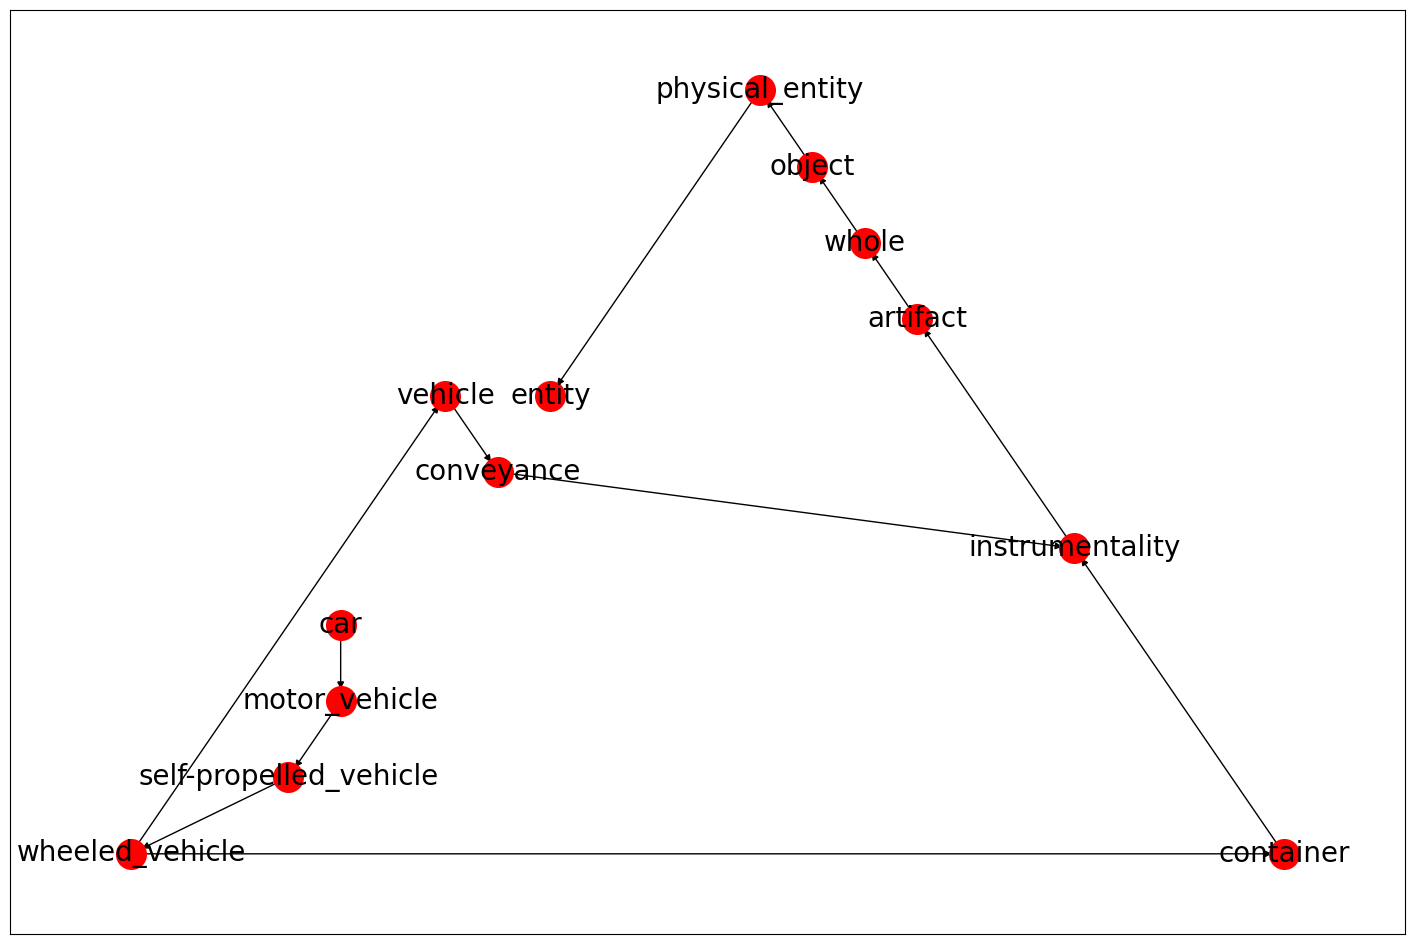

In [ ]:
print(ss[0].name())
G, labels = closure_graph(ss[0], fn = lambda s: s.hypernyms())
draw_text_graph(G, labels)

**Comentario:** POS (Part of Speech), también llamado etiquetado gramatical o etiquetado de palabras por categorias, consiste en etiquetar la categoria gramatical a la que pertence cada palabra en un volumen de texto, siendo las categorias:

1.   Sustantivos
2.   Adjetivos
3.   Articulos
4.   Pronombres
5.   Verbos
6.   Adverbios
7.   Interjecciones
8.   Preposiciones
9.   Conjunciones

#### Desambiguación del sentido de las palabras

Con todos estos casos de similitudes semánticas, entonces podemos construir frases problemáticas para la computadora.

- **"Estoy sentado en el *banco*, esperando mi turno para ser atendido"**

¿Cómo sabemos a qué clase de banco nos referimos?

Necesitamos que la computadora pueda comprender el contexto para reducir la ambigüedad de las palabras. Y se puede hacer mediante:

- Restricciones de selección
- Desambiguación robusta

##### Restricciones de selección

Pueden ser usadas para bloquear la formación de representaciones que contienen violaciones a la semántica y sintaxis. Encontrando componentes clave que nos brinden información suficiente para dar sentido a las palabras.

Por ejemplo:

- "Los platos que nos sirvieron en ese lujoso restaurante fueron maravillosos"
- "En la cocina de un restaurante se desempeñan varias tareas, una de ellas es lavar los platos"

_servir_ y _lavar_ funjen como los componentes clave para poder distinguir entre el significado de platos

##### Desambiguación robusta
Puede hacerse mediante:
- Aproximación desde el aprendizaje automático
- Aproximación basada en diccionarios

### Otras consideraciones
El lenguaje es vago, no siempre se utiliza en contextos formales y es ambiguo. Además, en contextos informales, se presta a variaciones complejas del mismo.

Algunos otros factores que afectan al lenguaje son:
- Insultos
- Abreviaciones
- Errores ortográficos
- Contextos sociales
- Estado emocional
- Velocidad de escritura
- Nivel de dominio del lenguaje
- Escritura 1337 (*leet*)
- Sarcasmo